# Assignment 2 Data Quality Assessment & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
import kagglehub
import os
# sns.set(style="whitegrid")

ModuleNotFoundError: No module named 'seaborn'

In [8]:
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\austinreese\craigslist-carstrucks-data\versions\10


In [12]:
path = os.path.join("vehicles.csv")
pd.set_option("display.max_columns", None)

df = pd.read_csv(path)

df.head(5)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [13]:
df.dtypes

id                int64
url              object
region           object
region_url       object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        object
description      object
county          float64
state            object
lat             float64
long            float64
posting_date     object
dtype: object

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [15]:
# Select relevant columns, we do not select 'model' (too many unique values, too sparse and will hurt the model performance)
cols = ['price', 'year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'transmission', 'type']
df_clean = df[cols].copy()

# Drop rows where target (price) or key features are missing
print(f"Before: {df_clean.shape}")
df_clean = df_clean.dropna(subset=['price', 'year', 'odometer'])
print(f"After dropping missing price/year/odometer: {df_clean.shape}")

Before: (426880, 9)
After dropping missing price/year/odometer: (421344, 9)


In [16]:
# Fill categorical columns with 'unknown'
for col in ['manufacturer', 'condition', 'fuel', 'transmission', 'type']:
    df_clean[col] = df_clean[col].fillna('unknown')

# Fill cylinders with mode
df_clean['cylinders'] = df_clean['cylinders'].fillna(df_clean['cylinders'].mode()[0])

print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


In [17]:
df_clean.head(5)

,price,year,manufacturer,condition,cylinders,fuel,odometer,transmission,type
27,33590,2014.0,gmc,good,8 cylinders,gas,57923.0,other,pickup
28,22590,2010.0,chevrolet,good,8 cylinders,gas,71229.0,other,pickup
29,39590,2020.0,chevrolet,good,8 cylinders,gas,19160.0,other,pickup
30,30990,2017.0,toyota,good,8 cylinders,gas,41124.0,other,pickup
31,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,automatic,truck


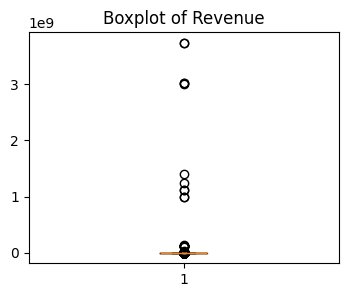

In [22]:
plt.figure(figsize=(4,3))
plt.boxplot(x=df_clean['price'])
plt.title("Boxplot of Revenue")
plt.show()

In [23]:
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['price'] < lower) | (df['price'] > upper)]
outliers.head(15)

C:\Users\Admin\AppData\Local\Temp\ipykernel_30636\2814350004.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df_clean[(df_clean['price'] < lower) | (df['price'] > upper)]


,price,year,manufacturer,condition,cylinders,fuel,odometer,transmission,type
204,58977,2019.0,gmc,unknown,6 cylinders,gas,66368.0,automatic,unknown
280,987654321,1960.0,chevrolet,unknown,6 cylinders,gas,999999.0,manual,unknown
346,98900,2001.0,ferrari,good,8 cylinders,gas,20187.0,automatic,convertible
365,72900,2021.0,chevrolet,good,8 cylinders,gas,19129.0,automatic,SUV
461,99950,2021.0,chevrolet,unknown,6 cylinders,gas,510.0,automatic,coupe
732,100000,1984.0,jeep,unknown,6 cylinders,gas,112000.0,manual,unknown
807,63990,2017.0,unknown,good,6 cylinders,diesel,28400.0,automatic,truck
829,62990,2016.0,ford,good,8 cylinders,diesel,40193.0,automatic,unknown
857,59990,2017.0,ford,good,8 cylinders,diesel,31337.0,automatic,truck
906,69950,2012.0,ford,unknown,6 cylinders,diesel,267001.0,automatic,unknown


In [24]:
df_no_outliers = df_clean[(df_clean['price'] >= lower) & (df_clean['price'] <= upper)]
print("Original shape: ",df_clean.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (421344, 9)
After removing outliers:  (413421, 9)


In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_clean[['price']].copy()

df_scaled[['price']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,price
27,0.000009
28,0.000006
29,0.000011
30,0.000008
31,0.000004


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_clean[['price', 'odometer']].copy()

df_standardized[['price', 'odometer']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,price,odometer
27,-0.003457,-0.188222
28,-0.004354,-0.126079
29,-0.002968,-0.369255
30,-0.003669,-0.266678
31,-0.004973,0.139057


In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['price']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

NameError: name 'sns' is not defined

<Figure size 600x400 with 0 Axes>

In [35]:
from sklearn.decomposition import PCA

X = df_standardized[['price', 'odometer']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50501592 0.49498408]


### This dataset can't use pca as its based on the price. On this dataset a model will predict the price.

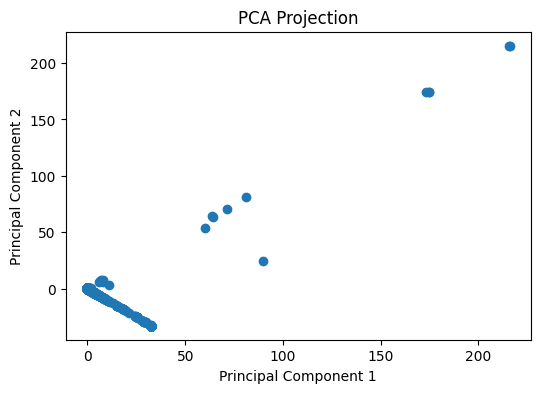

In [36]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Ali Albinali 2230003813 8MA2